In [15]:
import json
import os
import pandas as pd

In [16]:
result_files = os.listdir('../experiments/testing/final_results')
result_files = [col for col in result_files if '.json' in col and 'crashed' not in col]
result_files

['1049_13.json',
 '1067_13.json',
 '1111_13.json',
 '1169_13.json',
 '12_13.json',
 '1461_13.json',
 '1464_13.json',
 '1468_13.json',
 '1475_13.json',
 '1486_13.json',
 '1487_13.json',
 '1489_13.json',
 '1494_13.json',
 '1590_13.json',
 '1596_13.json',
 '181_13.json',
 '188_13.json',
 '23512_13.json',
 '23517_13.json',
 '23_13.json',
 '31_13.json',
 '3_13.json',
 '40498_13.json',
 '40668_13.json',
 '40670_13.json',
 '40685_13.json',
 '40701_13.json',
 '40900_13.json',
 '40975_13.json',
 '40978_13.json',
 '40981_13.json',
 '40982_13.json',
 '40983_13.json',
 '40984_13.json',
 '40996_13.json',
 '41027_13.json',
 '41138_13.json',
 '41142_13.json',
 '41143_13.json',
 '41144_13.json',
 '41145_13.json',
 '41146_13.json',
 '41147_13.json',
 '41150_13.json',
 '41156_13.json',
 '41157_13.json',
 '41158_13.json',
 '41159_13.json',
 '41161_13.json',
 '41162_13.json',
 '41163_13.json',
 '41164_13.json',
 '41165_13.json',
 '41166_13.json',
 '41167_13.json',
 '41168_13.json',
 '41169_13.json',
 '413

In [17]:
results_path = '../experiments/testing/final_results'
exp_records = []
for exp_file in result_files:
    exp_id = exp_file.split('.')[0]
    with open(os.path.join(results_path, exp_file), 'r') as f:
        data = json.load(f)
        exp_records.append(data)

exp_df = pd.DataFrame(exp_records)
exp_df.to_csv(os.path.join(results_path, 'summary', 'all_experiments.csv'), index=False)


In [18]:
display(exp_df.head())

,exp_id,data_id,seed,n_rows,n_features,hgb_accuracy,hgb_training_time_sec,mlp_training_time,mlp_train_acc,mlp_train_loss,...,ebe_benefit_est,ebe_cost_est,ebe_top_forecast_val_acc,ebe_top_forecast_CI_high,ebe_val_acc,ebe_test_acc,ebe_surpassed_val_baseline,ebe_surpassed_test_baseline,ebe_time_vs_hist_ratio,ebe_time_vs_mlp_ratio
0,1049_13,1049,13,1166,37,0.890411,0.196108,0.394073,0.958834,0.103086,...,0.072248,0.794942,0.991761,1.000000,0.000000,0.000000,False,False,307.234548,152.893456
1,1067_13,1067,13,1687,21,0.831754,0.106569,0.517114,0.891523,0.280045,...,0.089045,0.357454,0.991730,1.000000,0.846154,0.845972,False,True,105.963515,21.837474
2,1111_13,1111,13,40000,230,0.981700,0.929933,20.840523,0.999950,0.001663,...,0.020000,0.000000,1.000000,1.000000,0.000000,0.000000,False,False,65.327928,2.915023
3,1169_13,1169,13,431506,7,0.661197,0.999577,30.372907,0.647588,0.626072,...,0.020000,13.779446,0.651541,0.725599,0.000000,0.000000,False,False,60.878039,2.003505
4,12_13,12,13,1600,216,0.975000,4.242687,0.456228,1.000000,0.003325,...,0.020000,0.878559,0.994257,1.000000,0.000000,0.000000,False,False,14.200316,132.055679


In [19]:
exp_df.head().to_csv(os.path.join(results_path, 'summary', 'all_experiments_head.csv'), index=False)

In [20]:

# --- core decision stats ---
n_total = len(exp_df)
n_worthy = exp_df["ebe_decision"].sum()
prop_worthy = n_worthy / n_total

n_val_surpass = exp_df["ebe_surpassed_val_baseline"].sum()
n_test_surpass = exp_df["ebe_surpassed_test_baseline"].sum()

print(f"Total datasets: {n_total}")
print(f"Neural-worthy (EBE decided True): {n_worthy} ({prop_worthy:.1%})")
print(f"Surpassed validation baseline: {n_val_surpass} ({n_val_surpass/n_total:.1%})")
print(f"Surpassed test baseline: {n_test_surpass} ({n_test_surpass/n_total:.1%})")


Total datasets: 69
Neural-worthy (EBE decided True): 28 (40.6%)
Surpassed validation baseline: 4 (5.8%)
Surpassed test baseline: 4 (5.8%)


C:\Users\user\AppData\Local\Temp\ipykernel_226644\1958497668.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="ebe_decision", data=exp_df, palette="coolwarm")


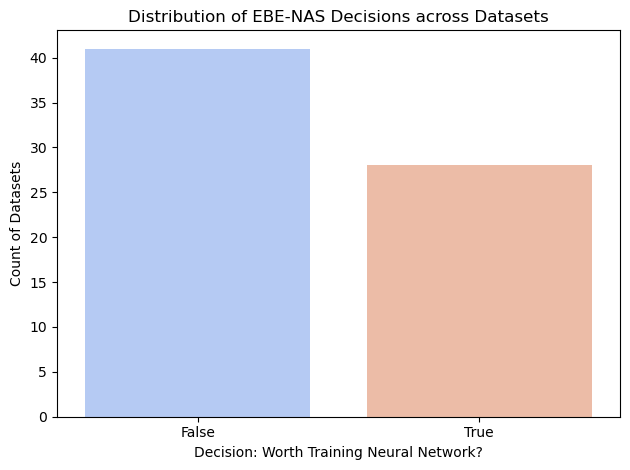

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="ebe_decision", data=exp_df, palette="coolwarm")
plt.title("Distribution of EBE-NAS Decisions across Datasets")
plt.xlabel("Decision: Worth Training Neural Network?")
plt.ylabel("Count of Datasets")
plt.tight_layout()
plt.savefig("../analysis_outputs/decision_distribution.png", dpi=300)


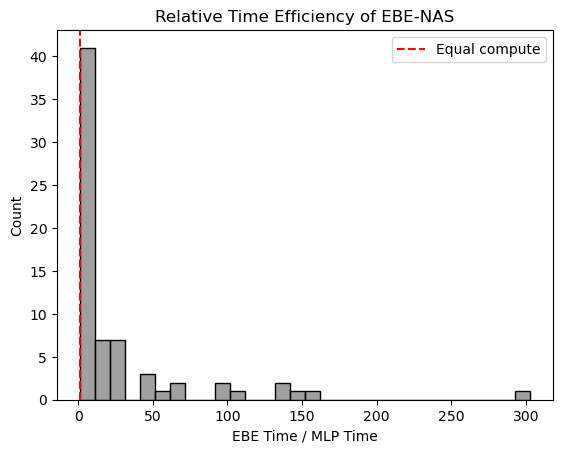

In [22]:
sns.histplot(exp_df["ebe_time_vs_mlp_ratio"], bins=30, color="gray")
plt.axvline(1, color="red", linestyle="--", label="Equal compute")
plt.legend()
plt.xlabel("EBE Time / MLP Time")
plt.title("Relative Time Efficiency of EBE-NAS")
plt.savefig("../analysis_outputs/time_efficiency_histogram.png", dpi=300)


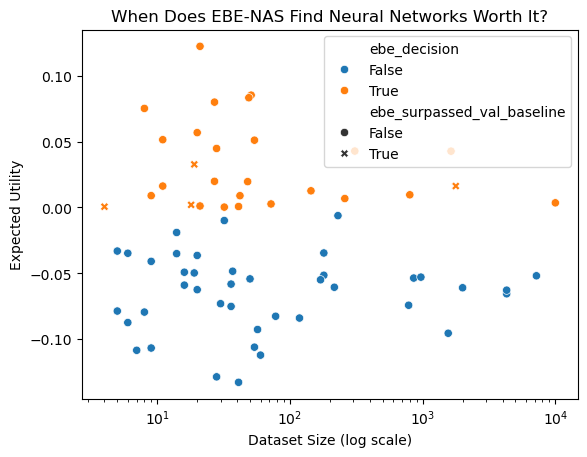

In [23]:
sns.scatterplot(
    x="n_features", y="ebe_expected_utility",
    hue="ebe_decision", style="ebe_surpassed_val_baseline", data=exp_df
)
plt.xscale("log")
plt.xlabel("Dataset Size (log scale)")
plt.ylabel("Expected Utility")
plt.title("When Does EBE-NAS Find Neural Networks Worth It?")
plt.savefig("../analysis_outputs/utility_vs_dataset_size.png", dpi=300)


In [24]:
summary = {
    "Total Datasets": [len(exp_df)],
    "Neural Worthy": [exp_df["ebe_decision"].sum()],
    "Validation Surpassed": [exp_df["ebe_surpassed_val_baseline"].sum()],
    "Test Surpassed": [exp_df["ebe_surpassed_test_baseline"].sum()],
    "Mean Expected Utility": [exp_df["ebe_expected_utility"].mean()],
    "Mean Probability p": [exp_df["ebe_p_above_goal"].mean()]
}
pd.DataFrame(summary).to_latex("../analysis_outputs/ebe_summary_overview.tex", index=False)
